In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
data = pd.read_excel('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Alzhimers.xlsx')
data.isnull().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Subject ID  373 non-null    bool 
 1   MRI ID      373 non-null    bool 
 2   Group       373 non-null    bool 
 3   Visit       373 non-null    bool 
 4   MR Delay    373 non-null    bool 
 5   M/F         373 non-null    bool 
 6   Hand        373 non-null    bool 
 7   Age         373 non-null    bool 
 8   EDUC        373 non-null    bool 
 9   SES         373 non-null    bool 
 10  MMSE        373 non-null    bool 
 11  CDR         373 non-null    bool 
 12  eTIV        373 non-null    bool 
 13  nWBV        373 non-null    bool 
 14  ASF         373 non-null    bool 
dtypes: bool(15)
memory usage: 5.6 KB


In [2]:
data.drop(['Subject ID', 'MRI ID', 'Hand'], axis=1, inplace=True)
data.isnull().sum()

Group        0
Visit        0
MR Delay     0
M/F          0
Age          0
EDUC         0
SES         19
MMSE         2
CDR          0
eTIV         0
nWBV         0
ASF          0
dtype: int64

In [3]:
data['SES'].mean()

2.4604519774011298

In [4]:
data['MMSE'].mean()

27.342318059299192

In [5]:
data['SES'].fillna(2.46, inplace=True)
data['MMSE'].fillna(27.34, inplace=True)

In [6]:
data.isnull().sum()

Group       0
Visit       0
MR Delay    0
M/F         0
Age         0
EDUC        0
SES         0
MMSE        0
CDR         0
eTIV        0
nWBV        0
ASF         0
dtype: int64

In [7]:
data.drop('Group', axis=1, inplace=True)
data.replace({'M/F':{'M':1, 'F':0}}, inplace=True)

In [8]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
print(f"Data Shape: {data.shape}")
print(f"Colummns:{list(data.columns)}")

Data Shape: (373, 11)
Colummns:['Visit', 'MR Delay', 'M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']


In [9]:
from sdv.single_table import(
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer
)

models = {

    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

In [10]:
# model fitting 

for name, model in models.items():
    print(f"Fitting {name}....")
    model.fit(data)
print('All models fitted')

Fitting GaussianCopula....
Fitting CTGAN....
Fitting CopulaGAN....
Fitting TVAE....
All models fitted


In [11]:
from numpy.linalg import norm
synthetic_data = {}
n_rows = len(data)

for name, model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)

def normalize_rows(X):
    return X/(norm(X, axis=1, keepdims=True)+1e-12)

real_matrix = normalize_rows(data.to_numpy(float))

cosine_results = {}

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Visit     373 non-null    int64  
 1   MR Delay  373 non-null    int64  
 2   M/F       373 non-null    int64  
 3   Age       373 non-null    int64  
 4   EDUC      373 non-null    int64  
 5   SES       373 non-null    float64
 6   MMSE      373 non-null    float64
 7   CDR       373 non-null    float64
 8   eTIV      373 non-null    float64
 9   nWBV      373 non-null    float64
 10  ASF       373 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 32.2 KB


In [13]:
cosine_dfs = {}  # store results for all models

for model_name, synth_df in synthetic_data.items():

    print(f"Building cosine similarity DataFrame for {model_name}...")

    # Normalize synthetic matrix
    synth_matrix = normalize_rows(synth_df.to_numpy(float))

    # Compute cosine similarity matrix
    cosine_matrix = real_matrix @ synth_matrix.T

    # Build DataFrame (first 10x10 block for readability)
    cosine_df = pd.DataFrame(
        cosine_matrix[:373, :373],  # top-left 10×10 portion
        index=[f"R{i+1}" for i in range(373)],
        columns=[f"S{j+1}" for j in range(373)]
    )

    # Save in dictionary
    cosine_dfs[model_name] = cosine_df

    print(cosine_df, "\n")

Building cosine similarity DataFrame for GaussianCopula...
            S1        S2        S3        S4        S5        S6        S7  \
R1    0.999988  0.999739  0.999955  0.999863  0.999960  0.999753  0.999857   
R2    0.975688  0.974796  0.974999  0.977406  0.975003  0.974802  0.975690   
R3    0.999989  0.999758  0.999962  0.999872  0.999966  0.999773  0.999871   
R4    0.952797  0.951667  0.951862  0.955218  0.951865  0.951665  0.952853   
R5    0.669976  0.667626  0.667745  0.676059  0.667747  0.667643  0.670329   
...        ...       ...       ...       ...       ...       ...       ...   
R369  0.896921  0.895473  0.895591  0.900533  0.895598  0.895473  0.897120   
R370  0.595121  0.592660  0.592722  0.601742  0.592727  0.592667  0.595552   
R371  0.999974  0.999856  0.999982  0.999907  0.999987  0.999810  0.999921   
R372  0.868626  0.867057  0.867153  0.872691  0.867157  0.867020  0.868870   
R373  0.641027  0.638685  0.638746  0.647353  0.638748  0.638660  0.641441   

    

In [14]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

# ---------- cosine similarity (reuse your earlier function) ----------

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    return R_norm @ S_norm.T


# ---------- Hungarian-based optimal matching ----------

def hungarian_match(real_df: pd.DataFrame,
                    synth_df: pd.DataFrame,
                    num_cols=None):

    # NOTE: call cosine_similarity_matrix (not cosine_matrix)
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # We want to maximize similarity → minimize cost = 1 - similarity
    if n_real <= n_synth:
        cost_matrix = 1.0 - cos_sim
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]
    else:
        cost_matrix = 1.0 - cos_sim.T
        col_ind, row_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())
    return row_ind, col_ind, selected_similarities, avg_similarity, cos_sim


# ---------- 1. Fit the four models ----------

real_df = data  # your real Wisconsin dataset

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN":          CTGANSynthesizer,
    "CopulaGAN":      CopulaGANSynthesizer,
    "TVAE":           TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=len(real_df))


# ---------- 2. Run Hungarian matching for each model ----------

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
        real_df, synth_df, num_cols=None
    )

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    # show first 10 matched pairs
    for k in range(min(10, len(row_ind))):
        r_idx = row_ind[k]
        s_idx = col_ind[k]
        sim_val = sims[k]
        print(f"R{r_idx+1} ↔ S{s_idx+1}   cosine similarity = {sim_val:.4f}")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9290

R1 ↔ S188   cosine similarity = 1.0000
R2 ↔ S127   cosine similarity = 0.9751
R3 ↔ S252   cosine similarity = 1.0000
R4 ↔ S183   cosine similarity = 0.9521
R5 ↔ S136   cosine similarity = 0.8073
R6 ↔ S44   cosine similarity = 1.0000
R7 ↔ S41   cosine similarity = 0.9140
R8 ↔ S114   cosine similarity = 1.0000
R9 ↔ S249   cosine similarity = 0.8721
R10 ↔ S203   cosine similarity = 0.7994

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9849

R1 ↔ S41   cosine similarity = 1.0000
R2 ↔ S16   cosine similarity = 0.9795
R3 ↔ S166   cosine similarity = 1.0000
R4 ↔ S297   cosine similarity = 0.9657
R5 ↔ S228   cosine similarity = 0.9915
R6 ↔ S30   cosine similarity = 1.0000
R7 ↔ S108   cosine similarity = 0.9610
R8 ↔ S266   cosine similarity 

In [15]:
gc_model   = GaussianCopulaSynthesizer(metadata=metadata)
ctgan_model = CTGANSynthesizer(metadata=metadata)
cop_model   = CopulaGANSynthesizer(metadata=metadata)
tvae_model  = TVAESynthesizer(metadata=metadata)

# Fit models
gc_model.fit(data)
ctgan_model.fit(data)
cop_model.fit(data)
tvae_model.fit(data)

# Sample 1500 rows from each model
synthetic_data_gaussian_copula = gc_model.sample(num_rows=1000)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=1000)
synthetic_data_copulagan       = cop_model.sample(num_rows=1000)
synthetic_data_tvae            = tvae_model.sample(num_rows=1000)

# Show structure
print("\nGaussianCopula synthetic data:")
synthetic_data_gaussian_copula.info()

print("\nCTGAN synthetic data:")
synthetic_data_ctgan.info()

print("\nCopulaGAN synthetic data:")
synthetic_data_copulagan.info()

print("\nTVAE synthetic data:")
synthetic_data_tvae.info()


GaussianCopula synthetic data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Visit     1000 non-null   int64  
 1   MR Delay  1000 non-null   int64  
 2   M/F       1000 non-null   int64  
 3   Age       1000 non-null   int64  
 4   EDUC      1000 non-null   int64  
 5   SES       1000 non-null   float64
 6   MMSE      1000 non-null   float64
 7   CDR       1000 non-null   float64
 8   eTIV      1000 non-null   float64
 9   nWBV      1000 non-null   float64
 10  ASF       1000 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 86.1 KB

CTGAN synthetic data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Visit     1000 non-null   int64  
 1   MR Delay  1000 non-null   int64  
 2   M/F       1000

In [16]:
# lets create synthetic data with 5000 samples

synthetic_data_gaussian_copula = gc_model.sample(num_rows=2000)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=2000)
synthetic_data_copulagan       = cop_model.sample(num_rows=2000)
synthetic_data_tvae            = tvae_model.sample(num_rows=2000)

In [17]:
# Cluster synthetic data and match real to centroids

from sklearn.cluster import KMeans

def cluster_synthetic_and_match(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols,
                                n_clusters: int = None,
                                random_state: int = 0):

    # Extract numeric data
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    n_real = R.shape[0]


    if n_clusters is None:
        n_clusters = n_real

    # Normalize synthetic data for clustering (cosine ~ Euclidean on unit sphere)
    S_norm = normalize_rows(S)

    # ---------- KMeans clustering on synthetic samples ----------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state,
                    n_init=10)
    kmeans.fit(S_norm)

    # Centroids are in normalized space; we can treat them as direction vectors
    centroids = kmeans.cluster_centers_        # shape: (K, d)
    centroids_norm = normalize_rows(centroids) # just to be safe

    # Normalize real data for cosine similarity
    R_norm = normalize_rows(R)

    # ---------- Cosine similarity: real vs centroids ----------
    # cos_sim[i, k] = cosine similarity between real i and centroid k
    cos_sim_matrix = R_norm @ centroids_norm.T   # shape: (N_real, K)

    # For each real sample, find the closest centroid (max cosine similarity)
    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[np.arange(n_real), centroid_assignments]

    return (centroid_assignments,
            centroid_similarities,
            centroids,
            cos_sim_matrix,
            kmeans.labels_)

In [18]:
real_df = data

# Use ALL numeric features from the dataset
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
# print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# Dict of synthetic DATAFRAMES (make sure these exist already and have same columns)
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

cluster_results = {}

for model_name, synth_df in synthetic_tables.items():
    print("\n===================================================")
    print(f"{model_name}: clustering synthetic and matching to real (all numeric features)")
    print("===================================================\n")

    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,          # <-- all numeric features here
        n_clusters=len(real_df),    # usually use |R|
        random_state=42
    )

    # Store results
    cluster_results[model_name] = {
        "centroid_assignments": centroid_assignments,
        "centroid_sims": centroid_sims,
        "centroids": centroids,
        "cos_sim_centroids": cos_sim_centroids,
        "synth_cluster_labels": synth_cluster_labels,
    }

    print("Real → Centroid assignments (|S| >> |R|, clustered):\n")
    for i, (c_idx, sim) in enumerate(zip(centroid_assignments, centroid_sims)):
        r_name = f"R{i+1}"
        print(f"{r_name}  →  Centroid {c_idx}   cosine similarity = {sim:.4f}")

    avg_centroid_sim = float(centroid_sims.mean())
    print(f"\nAverage cosine similarity (real vs assigned centroid): {avg_centroid_sim:.4f}")

    print("\nNumber of synthetic samples per cluster (approx per real):")
    cluster_counts = np.bincount(synth_cluster_labels)
    for k, count in enumerate(cluster_counts):
        print(f"Cluster {k}: {count} synthetic samples")


GaussianCopula: clustering synthetic and matching to real (all numeric features)

Real → Centroid assignments (|S| >> |R|, clustered):

R1  →  Centroid 212   cosine similarity = 1.0000
R2  →  Centroid 239   cosine similarity = 1.0000
R3  →  Centroid 212   cosine similarity = 1.0000
R4  →  Centroid 123   cosine similarity = 1.0000
R5  →  Centroid 10   cosine similarity = 0.9999
R6  →  Centroid 34   cosine similarity = 1.0000
R7  →  Centroid 62   cosine similarity = 0.9999
R8  →  Centroid 233   cosine similarity = 1.0000
R9  →  Centroid 185   cosine similarity = 1.0000
R10  →  Centroid 23   cosine similarity = 0.9999
R11  →  Centroid 336   cosine similarity = 1.0000
R12  →  Centroid 204   cosine similarity = 1.0000
R13  →  Centroid 23   cosine similarity = 0.9999
R14  →  Centroid 34   cosine similarity = 1.0000
R15  →  Centroid 223   cosine similarity = 0.9999
R16  →  Centroid 72   cosine similarity = 1.0000
R17  →  Centroid 206   cosine similarity = 1.0000
R18  →  Centroid 363   cosine

Using 11 numeric features:
['Visit', 'MR Delay', 'M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

=== PCA + clustering for GaussianCopula ===


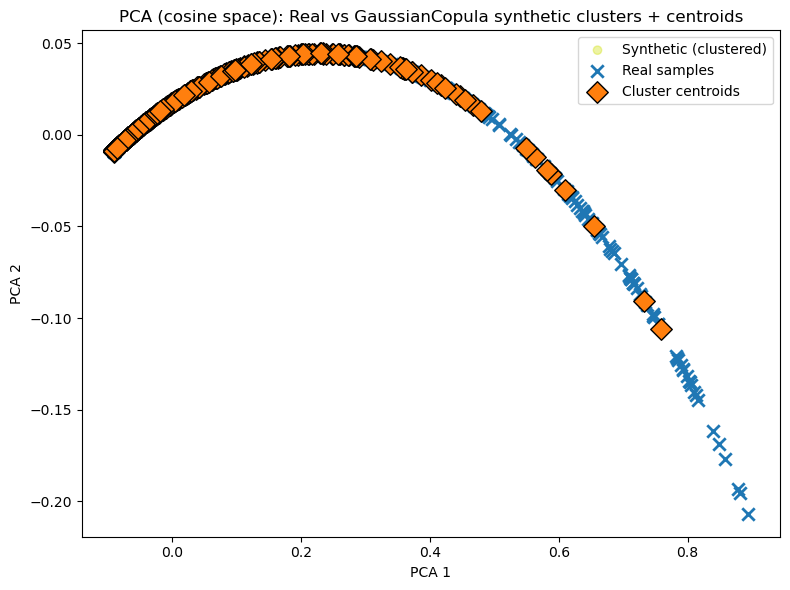


=== PCA + clustering for CTGAN ===


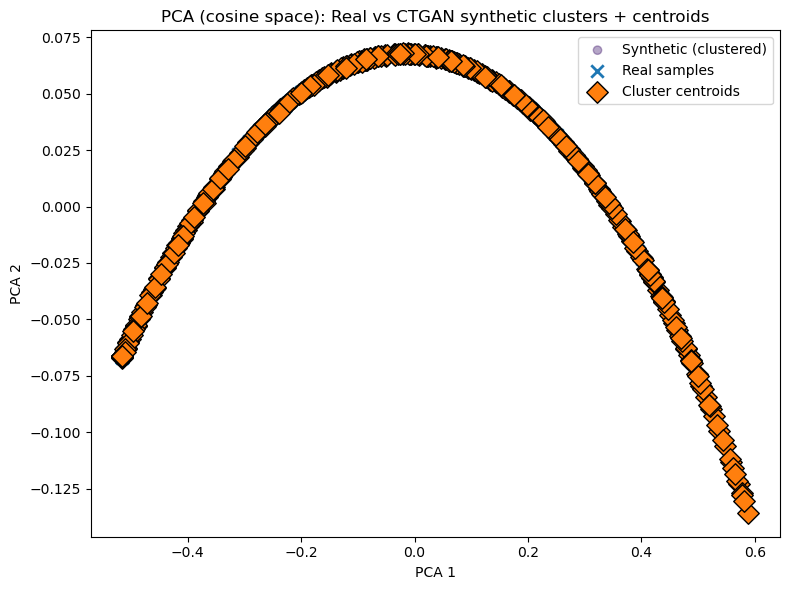


=== PCA + clustering for CopulaGAN ===


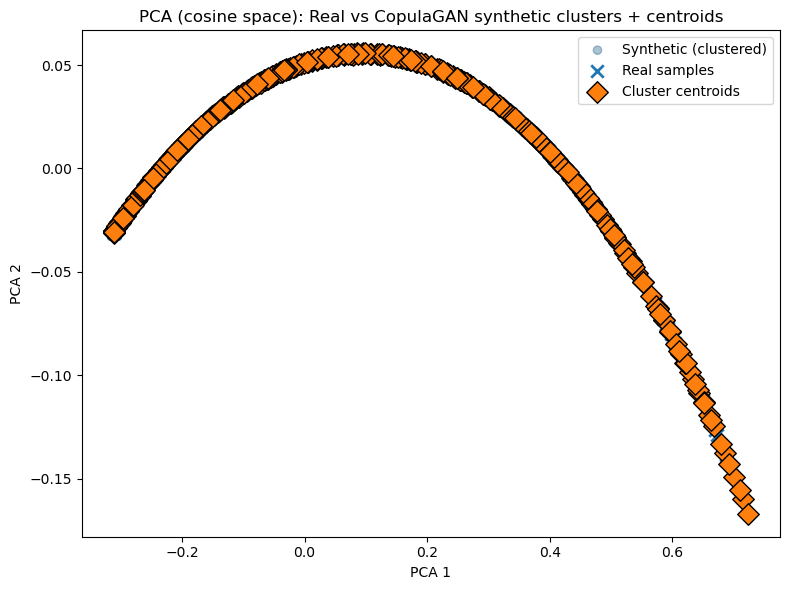


=== PCA + clustering for TVAE ===


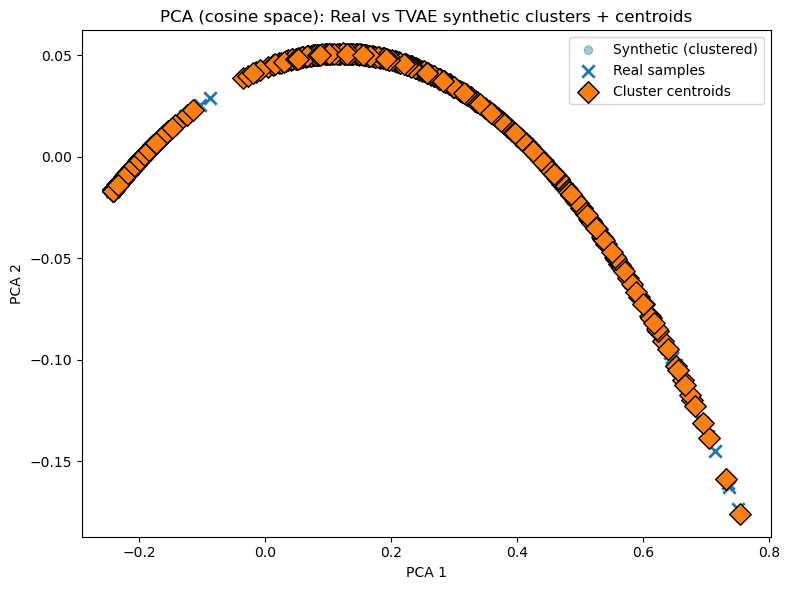

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

real_df = data

# Use all numeric features
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# Dict of synthetic DATAFRAMES for four models
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== PCA + clustering for {model_name} ===")

    # 1. Cluster synthetic and match to real (|S| >> |R|)
    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,
        n_clusters=len(real_df),   # typically |R|
        random_state=42
    )

    # 2. Build matrices in cosine-normalized space
    X_real = real_df[num_cols].to_numpy(dtype=float)
    X_synth = synth_df[num_cols].to_numpy(dtype=float)

    X_real_norm = normalize_rows(X_real)
    X_synth_norm = normalize_rows(X_synth)
    centroids_norm = normalize_rows(centroids)

    n_real = X_real_norm.shape[0]
    n_synth = X_synth_norm.shape[0]
    n_centroids = centroids_norm.shape[0]

    # 3. Stack and fit PCA on unified normalized space
    X_all_norm = np.vstack([X_real_norm, X_synth_norm, centroids_norm])
    pca = PCA(n_components=2)
    X_all_2d = pca.fit_transform(X_all_norm)

    # 4. Split back into real, synthetic, and centroids
    X_real_2d = X_all_2d[:n_real]
    X_synth_2d = X_all_2d[n_real:n_real + n_synth]
    X_centroids_2d = X_all_2d[n_real + n_synth:]

    # 5. Plot
    plt.figure(figsize=(8, 6))

    # Synthetic samples (coloured by cluster label)
    plt.scatter(
        X_synth_2d[:, 0],
        X_synth_2d[:, 1],
        c=synth_cluster_labels,
        alpha=0.4,
        marker='o',
        label="Synthetic (clustered)"
    )

    # Real samples
    plt.scatter(
        X_real_2d[:, 0],
        X_real_2d[:, 1],
        marker='x',
        s=80,
        linewidths=2,
        label="Real samples"
    )

    # Cluster centroids
    plt.scatter(
        X_centroids_2d[:, 0],
        X_centroids_2d[:, 1],
        marker='D',
        s=120,
        edgecolors='black',
        label="Cluster centroids"
    )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA (cosine space): Real vs {model_name} synthetic clusters + centroids")
    plt.legend()
    plt.tight_layout()
    plt.show()